# 1. Judul



"**Analisis dan Rekomendasi Produk Kemeja Pria Menggunakan Web Scraping dan Data Analysis dari Zalora**"

=================================================

**Definisi** :
Proyek ini bertujuan untuk mengumpulkan dan menganalisis data produk kemeja pria dari platform e-commerce Zalora menggunakan teknik web scraping. Data yang diperoleh kemudian diproses melalui tahap data cleaning, exploratory data analysis (EDA), serta filtering berdasarkan kriteria tertentu untuk menghasilkan rekomendasi produk terbaik yang sesuai dengan kebutuhan pengguna.

=================================================

# 2. Pernyataan Masalah

Masalah:
- Saya membutuhkan beberapa kemeja baru untuk menghadiri berbagai acara dalam satu minggu ke depan, namun memiliki anggaran yang terbatas.

Tujuan Analisis:
- Mengidentifikasi produk kemeja pria yang memiliki kombinasi terbaik antara harga yang terjangkau, popularitas produk, dan rating pelanggan yang tinggi.

Kriteria Pemilihan:
- Produk termasuk kategori "Paling Populer"
- Harga produk di bawah Rp500.000
- Produk memiliki rating pelanggan yang tinggi

# 3. Technical Workflow

Dalam proyek ini, beberapa teknologi digunakan untuk mendukung proses pengolahan data:

- Selenium digunakan untuk melakukan otomatisasi browser dalam proses web scraping.
- BeautifulSoup digunakan untuk melakukan parsing HTML dan mengekstrak informasi produk.
- Pandas digunakan untuk proses data cleaning, transformasi data, serta analisis data.
- Matplotlib dan Seaborn digunakan untuk melakukan visualisasi data dalam tahap exploratory data analysis (EDA).
- SQLAlchemy digunakan untuk menyimpan hasil data ke dalam database SQLite.

## 3.1 Install Library


In [1]:
# Instalasi library Selenium untuk otomatisasi browser
!pip install bs4 selenium


In [2]:
# Instalasi Pandas untuk pengolahan data
!pip install pandas

In [3]:
# Instalasi matplitlib dan seaborn untuk data visualisasi
!pip install matplotlib
!pip install seaborn

## 3.2 Import Library

In [4]:
# Mengimpor Pandas untuk manipulasi dataframe
import pandas as pd
# Menggunakan BeautifulSoup untuk parsing HTML
from bs4 import BeautifulSoup
# Menggunakan Selenium untuk otomatisasi browser
from selenium import webdriver
# Menggunakan Requests untuk melakukan HTTP request ke website target
import requests
# Menggunakan time untuk memberikan jeda waktu pada saat perpindahan halaman
import time

import re

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Melakukan validasi akses situs. Jika respon bernilai 200 (OK), maka situs tersebut dapat diproses untuk scraping
requests.get('https://www.zalora.co.id/c/men/pakaian/sale/c-26?vc_applicable=true&categoryId=31&page=1')

<Response [200]>

In [6]:
# Untuk membuka browser otomatisasi
driver =  webdriver.Chrome()


In [7]:
# Untuk menutup browser otomatisasi
driver.close()

## 3.3 Data Collecting

Implementasi Web Scraping pada Zalora.co.id

In [11]:
# Menjalankan webdriver
driver =  webdriver.Chrome()

# Membuat variable data, memiliki 5 data (kolom)
nama_produk = []
harga_produk = []
nama_toko = []
rating_produk = []
trending = []

# Melakukan scrapping hingga halaman ke 10
for page in range(1,11):
    # Memasukkan link yang dituju
    web_link = f'https://www.zalora.co.id/c/men/pakaian/sale/c-26?vc_applicable=true&categoryId=31&page={page}'
    driver.get(web_link)
    # melakukan jeda 1s
    time.sleep(1)
    # browser membuka halaman yang dituju
    html = driver.page_source
    # variable untuk mengambil html
    soup = BeautifulSoup(html, 'html.parser')
    # variable yang berisikan mengambil semua data pada 1 kotak produk
    kotak_produk = soup.find_all('div', {'class': 'flex flex-col min-h-[358px] tablet:min-h-[380px] desktop:min-h-[500px]'})

# Memasukkan data ke variable kotak_produk
    for data in kotak_produk:
        try:
            # scrapping html 'Nama Produk' ke dalam data
            print(data.find('h3', {'data-test-id' : 'productTitle'}))
            nama_produk.append(data.find('h3', {'data-test-id' : 'productTitle'}).get_text())
        except:
            #apabila tidak ada input, dialihkan menjadi 'None'
            print(None)
            nama_produk.append(None)
        try:
            # scrapping html 'Harga Produk' ke dalam data
            print(data.find('div', {"data-test-id":"originalPrice"}))
            harga_produk.append(data.find('div', {"data-test-id":"originalPrice"}).get_text())
        except:
            #apabila tidak ada input, dialihkan menjadi 'None'
            print(None)
            harga_produk.append(None)
        try:
            # scrapping html 'Nama Toko' ke dalam data
            print(data.find('h3', {'data-test-id' : "productBrandName"}))
            nama_toko.append(data.find('h3', {'data-test-id' : "productBrandName"}).get_text())
        except:
            #apabila tidak ada input, dialihkan menjadi 'None'
            print(None)
            nama_toko.append(None)
        try:
            # scrapping html 'Rating Produk' ke dalam data
            print(data.find('span', {"class" : "text-xxs font-medium leading-3 text-grey-60"}))
            rating_produk.append(data.find('span', {"class" : "text-xxs font-medium leading-3 text-grey-60"}).get_text())
        except:
            #apabila tidak ada input, dialihkan menjadi 'None'
            print(None)
            rating_produk.append(None)
        try:
            # scrapping html 'Trending' ke dalam data
            print(data.find('span', {"class" : "text-[#34669F]"}))
            trending.append(data.find('span', {"class" : "text-[#34669F]"}).get_text())
        except:
            #apabila tidak ada input, dialihkan menjadi 'None'
            print(None)
            trending.append(None)

<h3 class="overflow-hidden text-ellipsis whitespace-nowrap text-sm" data-test-id="productTitle">MOC Kemeja Lengan Pendek Pria GODRIC-WHITE</h3>
<div class="max-w-full truncate text-grey-60 line-through tablet:text-xs text-xxs tablet:text-xs" data-test-id="originalPrice">Rp 259.900</div>
<h3 class="shrink-[10] truncate text-base font-bold" data-test-id="productBrandName" title="MOC">MOC</h3>
<span class="text-xxs font-medium leading-3 text-grey-60" data-test-id="rating">5.0</span>
None
None
<h3 class="overflow-hidden text-ellipsis whitespace-nowrap text-sm" data-test-id="productTitle">Cotton Well Ben Short Sleeve Oxford Shirt Mint Green | Kemeja Pria Lengan Pendek Basic Polos Hijau Muda</h3>
<div class="max-w-full truncate text-grey-60 line-through tablet:text-xs text-xxs tablet:text-xs" data-test-id="originalPrice">Rp 279.000</div>
<h3 class="shrink-[10] truncate text-base font-bold" data-test-id="productBrandName" title="Cotton Well">Cotton Well</h3>
<span class="text-xxs font-medium 

Masukkan Hasil Scrapping ke DataFrame

In [ ]:
# Membuat data frame, dan memasukkan data scrapping ke tiap kolom
df = pd.DataFrame()
df['Nama Produk'] = nama_produk
df['Harga Produk'] = harga_produk
df['Nama Toko'] = nama_toko
df['Rating Produk'] = rating_produk
df['Paling Populer'] = trending


In [ ]:
# Output Data
df

,Nama Produk,Harga Produk,Nama Toko,Rating Produk,Paling Populer
0,MOC Kemeja Lengan Pendek Pria GODRIC-WHITE,Rp 259.900,MOC,5.0,None
1,Cotton Well Ben Short Sleeve Oxford Shirt Mint...,Rp 279.000,Cotton Well,5.0,None
2,MOC Kemeja Lengan Pendek Pria Briscoe - Olive,Rp 279.900,MOC,4.9,None
3,Bsc Dillion 3,Rp 559.000,Hush Puppies,4.9,Paling Populer
4,Caspian Vertical Stripe Pattern Shirt,Rp 599.000,Obermain,4.9,Paling Populer
...,...,...,...,...,...
385,MOC Kemeja Lengan Panjang Stripes Pria Myles -...,Rp 299.900,MOC,5.0,None
386,GANT - Pakaian Pria - Reg Oxford Shirt - White,Rp 1.799.000,Gant,4.8,None
387,MEN'S WHITE LONG-SLEEVED SHIRT,Rp 349.900,VALINO,5.0,None
388,Gloaming Flanel Veterano Panjang Ashviro Pria,Rp 320.000,Gloaming,None,None


## 3.4 Data Cleaning

Data mentah hasil scraping seringkali mengandung karakter yang tidak diperlukan (seperti simbol mata uang atau teks tambahan). Tahap ini bertujuan untuk membersihkan data agar siap dianalisis secara numerik.

In [77]:
# Menampilkan 5 teratas
df.head()

,Nama Produk,Harga Produk,Nama Toko,Rating Produk,Paling Populer
0,MOC Kemeja Lengan Pendek Pria GODRIC-WHITE,Rp 259.900,MOC,5.0,None
1,Cotton Well Ben Short Sleeve Oxford Shirt Mint...,Rp 279.000,Cotton Well,5.0,None
2,MOC Kemeja Lengan Pendek Pria Briscoe - Olive,Rp 279.900,MOC,4.9,None
3,Bsc Dillion 3,Rp 559.000,Hush Puppies,4.9,Paling Populer
4,Caspian Vertical Stripe Pattern Shirt,Rp 599.000,Obermain,4.9,Paling Populer


In [78]:
# Mengecek Jumlah Missing Values
df.isnull().sum()

Nama Produk         0
Harga Produk        0
Nama Toko           0
Rating Produk      39
Paling Populer    315
dtype: int64

In [57]:
# Mengecek struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Nama Produk     390 non-null    object
 1   Harga Produk    390 non-null    object
 2   Nama Toko       390 non-null    object
 3   Rating Produk   351 non-null    object
 4   Paling Populer  75 non-null     object
dtypes: object(5)
memory usage: 15.4+ KB


In [79]:
# Mengecek Data duplikat
df.duplicated().sum()

20

Hasil dari pengecekkan struktur data terdapat beberapa data 'Missing Values' dan data 'Duplicates', serta format tipe data pada kolom 'Harga Produk' dan 'Rating Produk' perlu diubah menjadi numeric.

In [ ]:
# Mengubah nilai "None" menjadi "0" pada kolom 'Rating Produk'
df.loc[df['Rating Produk'].isna(), 'Rating Produk'] = 0
# Mengubah nilai "None" menjadi "Regular" pada kolom 'Rating Produk'
df.loc[df['Paling Populer'].isna(), 'Paling Populer'] = "Reguler"

In [80]:
# Mengubah nilai pada kolom 'Rating Produk' menjadi 'numeric'
df["Paling Populer"] = df["Paling Populer"].notna().astype(int)
# Menghilangkan 'Rp.' dan '.' pada kolom 'Harga Produk' agar tipe data bisa menjadi 'numeric'
df['Harga Produk'] = df['Harga Produk'].str.replace('Rp', '', regex = False).str.replace('.', '', regex = False)

In [81]:
# Menghapus Duplikat
df = df.drop_duplicates()

In [87]:
# Mengubah tipe data kolom 'Harga Produk' menjadi 'int'
df['Harga Produk'] = df['Harga Produk'].astype(int)
# Mengubah tipe data kolom 'Rating Produk' menjadi 'float'
df['Rating Produk'] = df['Rating Produk'].astype(float)

C:\Users\User\AppData\Local\Temp\ipykernel_11600\1540584728.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Harga Produk'] = df['Harga Produk'].astype(int)
C:\Users\User\AppData\Local\Temp\ipykernel_11600\1540584728.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rating Produk'] = df['Rating Produk'].astype(float)


Cleaning telah dilakukan, diperlukan pengecekkan hasil Cleaning

In [89]:
# Menampilkan 5 data teratas.
df.head() 

,Nama Produk,Harga Produk,Nama Toko,Rating Produk,Paling Populer
0,MOC Kemeja Lengan Pendek Pria GODRIC-WHITE,259900,MOC,5.0,0
1,Cotton Well Ben Short Sleeve Oxford Shirt Mint...,279000,Cotton Well,5.0,0
2,MOC Kemeja Lengan Pendek Pria Briscoe - Olive,279900,MOC,4.9,0
3,Bsc Dillion 3,559000,Hush Puppies,4.9,1
4,Caspian Vertical Stripe Pattern Shirt,599000,Obermain,4.9,1


In [90]:
# Mengecek Jumlah Missing Values
df.isnull().sum()


Nama Produk        0
Harga Produk       0
Nama Toko          0
Rating Produk     37
Paling Populer     0
dtype: int64

In [91]:
# Mengecek struktur data
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 370 entries, 0 to 389
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Nama Produk     370 non-null    object 
 1   Harga Produk    370 non-null    int32  
 2   Nama Toko       370 non-null    object 
 3   Rating Produk   333 non-null    float64
 4   Paling Populer  370 non-null    int32  
dtypes: float64(1), int32(2), object(2)
memory usage: 14.5+ KB


Pembersihan data berhasil.
1. Missing Values telah diubah menjadi nilai "Reguler" dan "0".
2. Nilai "Rp." berhasil dihilangkan.
3. Nilai pada 'Harga Produk' dan 'Rating Produk' menjadi nilai 'int'.
4. Data yang duplikat berhasil dihilangkan.

In [92]:
# DataFrame setelah dibersihkan
df



,Nama Produk,Harga Produk,Nama Toko,Rating Produk,Paling Populer
0,MOC Kemeja Lengan Pendek Pria GODRIC-WHITE,259900,MOC,5.0,0
1,Cotton Well Ben Short Sleeve Oxford Shirt Mint...,279000,Cotton Well,5.0,0
2,MOC Kemeja Lengan Pendek Pria Briscoe - Olive,279900,MOC,4.9,0
3,Bsc Dillion 3,559000,Hush Puppies,4.9,1
4,Caspian Vertical Stripe Pattern Shirt,599000,Obermain,4.9,1
...,...,...,...,...,...
385,MOC Kemeja Lengan Panjang Stripes Pria Myles -...,299900,MOC,5.0,0
386,GANT - Pakaian Pria - Reg Oxford Shirt - White,1799000,Gant,4.8,0
387,MEN'S WHITE LONG-SLEEVED SHIRT,349900,VALINO,5.0,0
388,Gloaming Flanel Veterano Panjang Ashviro Pria,320000,Gloaming,NaN,0


## 3.5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) bertujuan untuk memahami karakteristik dataset yang telah dikumpulkan melalui proses web scraping. Pada tahap ini dilakukan analisis statistik dan visualisasi data untuk mengidentifikasi pola, distribusi data, serta hubungan antar variabel.

### 3.5.1. Distribusi Harga

Analisis distribusi harga dilakukan untuk memahami sebaran harga produk yang tersedia pada dataset. Dengan melihat distribusi harga, kita dapat mengetahui kisaran harga yang paling umum serta mengidentifikasi adanya produk dengan harga yang sangat rendah atau sangat tinggi dibandingkan produk lainnya.

Distribusi harga divisualisasikan menggunakan histogram untuk melihat frekuensi produk pada setiap rentang harga.

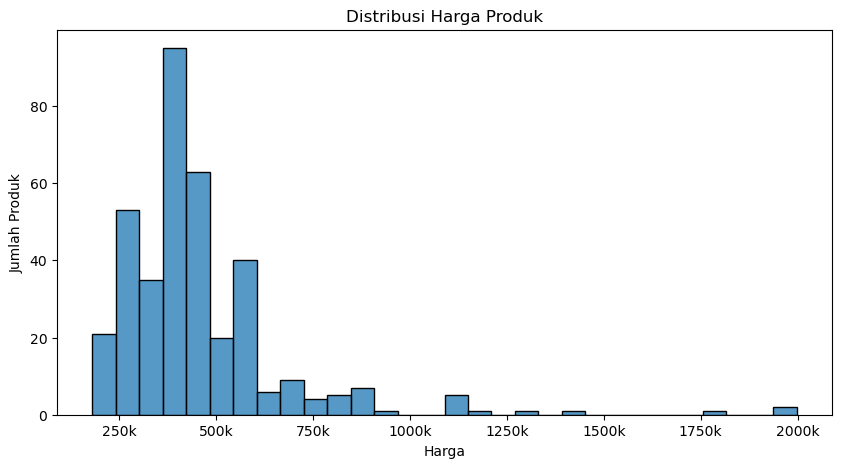

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


plt.figure(figsize=(10,5))
sns.histplot(df["Harga Produk"], bins=30)
plt.title("Distribusi Harga Produk")
plt.xlabel("Harga")
plt.ylabel("Jumlah Produk")
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))
plt.show()

Key Insight :

- Berdasarkan visualisasi distribusi harga produk, sebagian besar kemeja berada pada rentang harga antara Rp250.000 hingga Rp500.000. Hal ini menunjukkan bahwa kategori produk kemeja pria pada Zalora didominasi oleh produk dengan harga menengah yang relatif terjangkau bagi konsumen.

- Selain itu, terdapat beberapa produk dengan harga di atas Rp1.000.000 yang dapat dikategorikan sebagai produk premium, namun jumlahnya relatif sedikit dibandingkan produk dengan harga menengah.

### 3.5.2. Analisa Brand dengan Jumlah Produk Terbanyak

Analisis ini bertujuan untuk mengetahui brand atau toko mana yang memiliki jumlah produk paling banyak pada dataset. Informasi ini dapat memberikan gambaran mengenai brand yang paling aktif atau paling dominan dalam kategori produk yang dianalisis.

In [94]:
df["Nama Toko"].value_counts().head(10)

Nama Toko
Police Denim       52
Platini            46
AMK                34
Oxcon              25
MOC                23
Marks & Spencer    17
Cotton Well        13
Manzone            12
WOOD               11
Hush Puppies       11
Name: count, dtype: int64

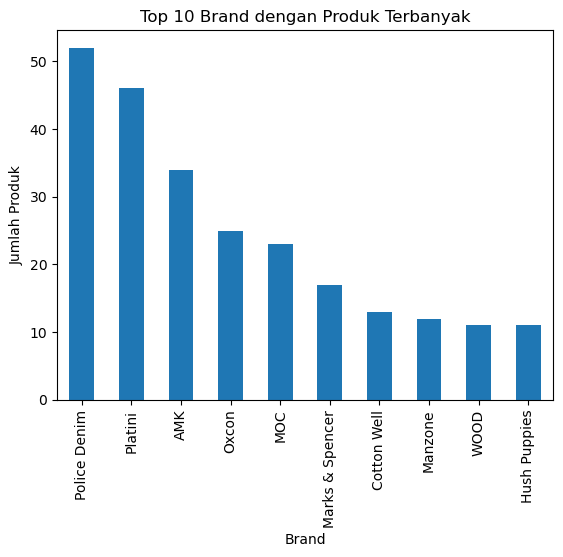

In [95]:
df["Nama Toko"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Brand dengan Produk Terbanyak")
plt.xlabel("Brand")
plt.ylabel("Jumlah Produk")
plt.show()

Insight:

- Analisis terhadap jumlah produk berdasarkan brand menunjukkan bahwa beberapa brand memiliki jumlah produk yang jauh lebih banyak dibandingkan brand lainnya. Hal ini mengindikasikan bahwa brand tersebut memiliki strategi katalog produk yang lebih luas atau lebih aktif dalam memasarkan produknya pada platform Zalora.

- Brand dengan jumlah produk yang lebih banyak cenderung memiliki peluang lebih tinggi untuk muncul dalam hasil pencarian pengguna, sehingga meningkatkan potensi visibilitas dan penjualan produk.

- Dominasi brand tertentu dalam dataset juga menunjukkan adanya konsentrasi pasar, di mana beberapa brand memiliki kehadiran yang lebih kuat dibandingkan brand lainnya dalam kategori produk tersebut.

### 3.5.3 Distribusi Rating Produk

Distribusi rating produk dianalisis untuk melihat bagaimana tingkat kepuasan pelanggan terhadap produk yang tersedia. Rating produk dapat menjadi indikator penting dalam menilai kualitas suatu produk.

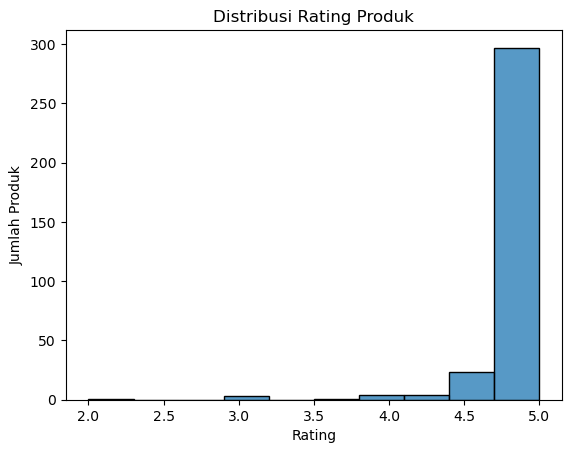

In [96]:
sns.histplot(df["Rating Produk"], bins=10)
plt.title("Distribusi Rating Produk")
plt.xlabel("Rating")
plt.ylabel("Jumlah Produk")
plt.show()

Insight: 

- Distribusi rating produk menunjukkan bahwa sebagian besar produk memiliki rating di atas 4.0. Hal ini mengindikasikan bahwa mayoritas produk dalam kategori ini memiliki tingkat kepuasan pelanggan yang cukup tinggi.

- Namun, terdapat beberapa produk yang tidak memiliki rating, yang kemungkinan disebabkan oleh produk yang belum memiliki cukup ulasan dari pelanggan.

### 3.5.4. Hubungan Harga dan Rating Produk

Analisis ini bertujuan untuk melihat apakah terdapat hubungan antara harga produk dengan rating yang diberikan oleh pelanggan. Visualisasi dilakukan menggunakan scatter plot.

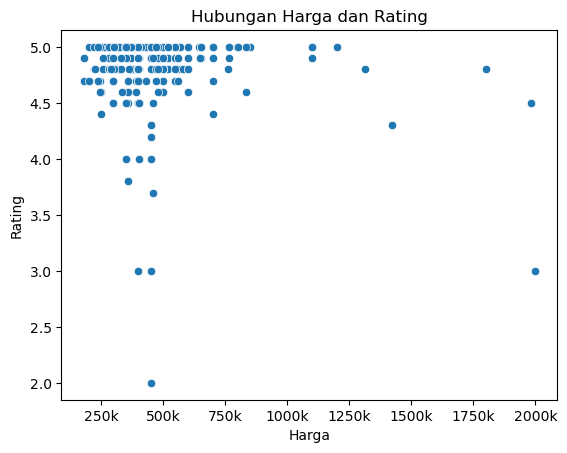

In [97]:
sns.scatterplot(x="Harga Produk", y="Rating Produk", data=df)
plt.title("Hubungan Harga dan Rating")
plt.xlabel("Harga")
plt.ylabel("Rating")
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))
plt.show()

Insight: 

- Berdasarkan visualisasi scatter plot, tidak terlihat hubungan yang kuat antara harga produk dan rating yang diberikan oleh pelanggan. Hal ini menunjukkan bahwa harga yang lebih tinggi tidak selalu menjamin rating yang lebih baik.

### 3.5.5. Analisis Produk Trending

Analisis ini dilakukan untuk mengetahui jumlah produk yang memiliki label trending dibandingkan dengan produk yang tidak memiliki label tersebut.

In [98]:
df["Paling Populer"].value_counts()

Paling Populer
0    301
1     69
Name: count, dtype: int64

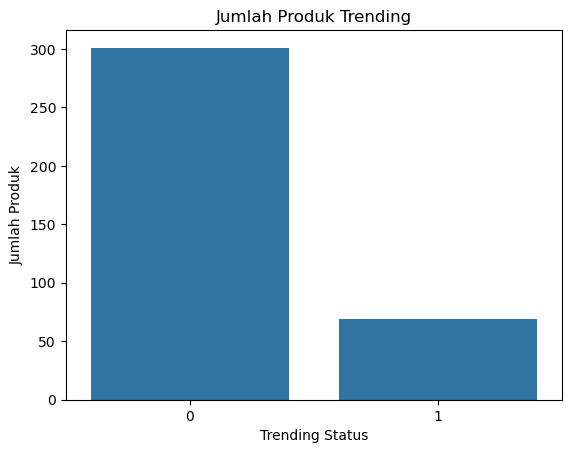

In [99]:
sns.countplot(x="Paling Populer", data=df)
plt.title("Jumlah Produk Trending")
plt.xlabel("Trending Status")
plt.ylabel("Jumlah Produk")
plt.show()

Insight

- Hasil analisis menunjukkan bahwa hanya sebagian kecil produk yang memiliki label "Paling Populer". Produk dengan label "Paling Populer" biasanya merupakan produk yang sedang populer atau banyak diminati oleh pelanggan.

### 3.5.6. Brand dengan Paling Populer

Analisis ini bertujuan untuk mengetahui brand yang memiliki rata-rata 'Paling Populer' tertinggi berdasarkan penilaian pelanggan.

In [100]:
df.groupby("Nama Toko")["Paling Populer"].mean().sort_values(ascending=False).head(10)

Nama Toko
Giordano           1.000000
Lois Jeans         1.000000
Edwin Jeans        0.750000
Hush Puppies       0.727273
Marks & Spencer    0.588235
Obermain           0.571429
ABIROY             0.500000
Blood & Bone       0.500000
Maginot            0.500000
WOOD               0.363636
Name: Paling Populer, dtype: float64

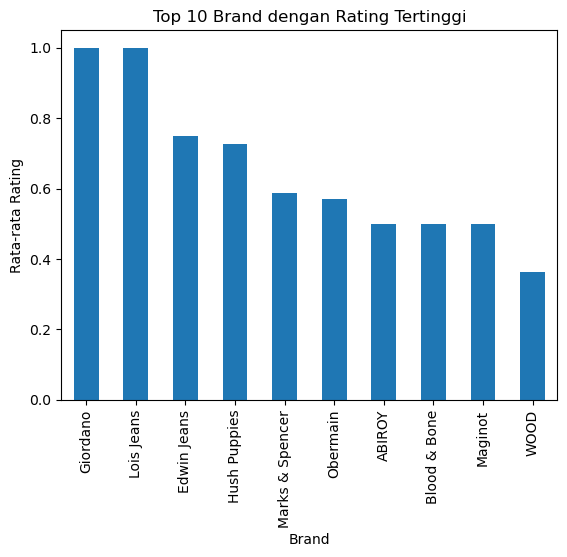

In [101]:
df.groupby("Nama Toko")["Paling Populer"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Brand dengan Rating Tertinggi")
plt.xlabel("Brand")
plt.ylabel("Rata-rata Rating")
plt.show()

Insight:

- Beberapa brand menunjukkan proporsi produk yang lebih tinggi dalam kategori "Paling Populer". Hal ini mengindikasikan bahwa brand tersebut memiliki daya tarik pasar yang lebih kuat dibandingkan brand lainnya.
- Popularitas ini kemungkinan dipengaruhi oleh faktor seperti reputasi brand, strategi pemasaran, maupun preferensi pelanggan terhadap produk dari brand tersebut.

### 3.5.7. Kesimpulan EDA

Berdasarkan hasil exploratory data analysis yang telah dilakukan, dapat disimpulkan bahwa: 
- Mayoritas produk pada kategori yang dianalisis memiliki harga pada kisaran menengah dengan distribusi rating yang relatif tinggi.
- Tidak ditemukan hubungan yang signifikan antara harga produk dan rating yang diberikan oleh pelanggan.
- Beberapa brand memiliki dominasi dalam jumlah produk serta memiliki rata-rata popularitas yang lebih tinggi dibandingkan brand lainnya.

## 3.7. Filtering Produk berdasarkan Kriteria

Untuk mendapatkan rekomendasi produk yang sesuai dengan kebutuhan, dilakukan proses filtering dataset berdasarkan kriteria yang telah ditentukan sebelumnya.

Kriteria Filtering:
- Produk memiliki label “Paling Populer”
- Harga produk kurang dari Rp500.000
- Produk memiliki rating pelanggan

In [105]:
rekomendasi = df[
    (df["Harga Produk"] < 500000) &
    (df["Paling Populer"] == 1) &
    (df["Rating Produk"].notna())
]

rekomendasi.sort_values(by="Rating Produk", ascending=False).head(10)

,Nama Produk,Harga Produk,Nama Toko,Rating Produk,Paling Populer
364,POLICE Kemeja Salur Printing Regular Fit Pria,399000,Police Denim,5.0,1
343,Cotton Dobby Shirt KLL602,479500,Lois Jeans,5.0,1
24,Long Sleeve Micro Stripe Shirt,429900,WOOD,5.0,1
242,Regular Fit Short Sleeve Oxford Shirt,399900,WOOD,5.0,1
206,MOC - Kemeja Batik Pria Lengan Panjang Baleren...,379900,MOC,5.0,1
171,Cotton Dobby Cheked Shirt KLS604,469500,Lois Jeans,5.0,1
148,BASTIEN - BLACK GREY Kemeja Flannel Casual Pri...,499900,Edwin Jeans,5.0,1
6,POLICE Kemeja Polos Oxford Slub Regular Fit Pr...,399000,Police Denim,4.9,1
102,Greggory Shirts,449900,X-EIGHT,4.9,1
220,POLICE Kemeja Abstrak Printing Navy Regular Fi...,399000,Police Denim,4.9,1


Berdasarkan hasil filtering, dapat dilihat bahwa terdapat beberapa produk yang berhasil memenuhi ketiga kriteria yang telah ditentukan. Produk-produk tersebut dapat dianggap sebagai produk yang memberikan nilai terbaik (best value) karena memiliki harga yang relatif terjangkau, termasuk dalam kategori produk populer, serta memiliki rating pelanggan yang tinggi.

Temuan ini menunjukkan bahwa konsumen masih dapat menemukan produk dengan kualitas yang baik meskipun memiliki keterbatasan anggaran, selama proses pemilihan produk dilakukan secara selektif berdasarkan data yang tersedia.

# 4. Kesimpulan

- Berdasarkan hasil analisis data yang dilakukan terhadap produk kemeja pria dari platform Zalora, dapat disimpulkan bahwa teknik web scraping berhasil digunakan untuk mengumpulkan informasi produk seperti nama produk, harga, nama brand, rating pelanggan, serta status popularitas produk.

- Setelah melalui tahap data cleaning, dataset dianalisis menggunakan exploratory data analysis (EDA) untuk memahami karakteristik data, termasuk distribusi harga produk, distribusi rating pelanggan, serta popularitas produk di berbagai brand.

- Hasil analisis menunjukkan bahwa sebagian besar produk kemeja berada pada rentang harga Rp250.000 hingga Rp500.000 dengan rating pelanggan yang relatif tinggi. Hal ini menunjukkan bahwa kategori produk tersebut didominasi oleh produk dengan harga menengah yang tetap memiliki kualitas yang baik berdasarkan ulasan pelanggan.

- Selanjutnya dilakukan proses filtering berdasarkan kriteria yang telah ditentukan, yaitu produk yang termasuk kategori "Paling Populer", memiliki harga di bawah Rp500.000, serta memiliki rating pelanggan yang tinggi. Hasil filtering menghasilkan beberapa produk yang dapat direkomendasikan sebagai pilihan terbaik karena memenuhi seluruh kriteria tersebut.

- Secara keseluruhan, proyek ini menunjukkan bagaimana proses pengumpulan data melalui web scraping, pengolahan data, exploratory data analysis, serta filtering data dapat digunakan untuk mendukung pengambilan keputusan berbasis data dalam memilih produk yang paling sesuai dengan kebutuhan pengguna.

# 5. Penyimpanan Data

## 5.1 Export dataframe ke file .csv

In [106]:
# export 'df' menjadi .csv
df.to_csv('DataFrame Zalora (Before).csv')

In [107]:
# export 'rekomendasi' menjadi .csv
rekomendasi.to_csv('DataFrame Zalora (After).csv')

## 5.2 Export ke SQL

Untuk menjamin integritas dan skalabilitas data, hasil akhir disimpan ke dalam format database relasional (SQLite) agar mudah diintegrasikan dengan sistem lain di masa mendatang

### 5.2.1 Install sqalchemy

In [108]:
!pip install sqlalchemy

### 5.2.2 Ekspor DataFrame ke Format Database (.db dan .sql)

In [114]:
from sqlalchemy import create_engine
import sqlite3

# Membuat engine SQLite sementara bernama data.db
engine = create_engine("sqlite:///rekomendasi.db")

# Menyimpan DataFrame ke tabel bernama table_name di database SQLite.
rekomendasi.to_sql("rekomendasi", engine, if_exists="replace", index=False)

# Mengekspor database ke file SQL
conn = sqlite3.connect("rekomendasi.db")
with open("DataFrame Zalora (After).sql", "w") as f:
    for line in engine.raw_connection().iterdump():
        f.write(f"{line}\n")
